In [1]:
!python --version

Python 3.11.14


## Monai wiht EfficientNet-B0/B3 (lightweight, great for cell morphology)

![BO](images/EfficientNet-Architecture-diagram.png)

<br>

![B3](images/Architecture-of-EfficientNet-B0-with-MBConv-as-Basic-building-blocks.png)


### EfficientNet is lighter, faster, and more accurate than DenseNet for microscopy.

| Model | Input Size | Parameters | Notes |
|-------|-------|-------|-------|
|B0 | 224×224 | 5.3M  | fast, small GPU |
| B3 | 300×300 | 12M | higher accuracy for cellular phenotypes |

In [2]:
!nvidia-smi

Fri Feb 20 10:52:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.16             Driver Version: 580.126.16     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        On  |   00000000:01:00.0  On |                  N/A |
|  0%   57C    P8             35W /  350W |     515MiB /  24576MiB |      7%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os, sys
import numpy as np

# import pandas as pd
# from glob import glob
# from tqdm import tqdm

import matplotlib.pyplot as plt

from pathlib import Path
ROOT = Path().resolve().parent
SRC = os.path.join(ROOT, "src")

if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

print("ROOT:", ROOT)
print("SRC added:", SRC)

from libs.Basic import *
from libs.image_lib import *
from libs.neural_network_lib import *

import numpy
numpy.__version__

ROOT: /home/flavio/uv/cell_class
SRC added: /home/flavio/uv/cell_class/src


'1.26.4'

In [4]:
!nvidia-smi

Fri Feb 20 10:52:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.16             Driver Version: 580.126.16     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        On  |   00000000:01:00.0  On |                  N/A |
|  0%   57C    P8             40W /  350W |     477MiB /  24576MiB |     34%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torch.optim as optim
# from torch.optim.lr_scheduler import ExponentialLR
# from torch.utils.data import Dataset, DataLoader, Subset

print(">> Cuda Ok?", torch.cuda.is_available())

if torch.cuda.is_available():
    print("\t>> device counts:", torch.cuda.device_count())
    print("\t>> current device:", torch.cuda.current_device())
    print("\t>> device name:", torch.cuda.get_device_name(0))

print(">> torch version:", torch.__version__)

>> Cuda Ok? True
	>> device counts: 1
	>> current device: 0
	>> device name: NVIDIA GeForce RTX 3090
>> torch version: 2.10.0+cu130


In [6]:
import monai
monai.__version__

'1.5.2'

In [7]:
root_data = "../data"
os.listdir(root_data)

['tables', 'samples', 'segment', 'crop', 'train_and_test']

In [8]:
cp = Cellpose(root0_data=root_data, verbose=True)

torch: 2.10.0+cu130

------- logger_setup() -----------
2026-02-20 10:52:19,112 [INFO] WRITING LOG OUTPUT TO /home/flavio/.cellpose/run.log
2026-02-20 10:52:19,113 [INFO] 
cellpose version: 	4.0.8 
platform:       	linux 
python version: 	3.11.14 
torch version:  	2.10.0+cu130
(<Logger cellpose.io (INFO)>, PosixPath('/home/flavio/.cellpose/run.log'))
2026-02-20 10:52:19,113 [INFO] ** TORCH CUDA version installed and working. **

------- GPU Ok -----------
>> current_device: 0
>> Device: NVIDIA GeForce RTX 3090
>> CUDA: 13.0 

>> torch.version.cuda: 13.0

Please set plate and experiment using create_roots(plate, experiment)



In [9]:
cp.set_default_parameters(root_yaml='..', verbose=True)

>> model_name   resnet18
>> crop_segment crop
>> dic_plate    5
>> ncrop    5


In [10]:
cp.root_samples, cp.root_crop

('../data/samples', '../data/crop')

In [11]:
plates = cp.list_plates(s_start='Plate')
plates

['Plate1847', 'Plate1896', 'Plate1849', 'Plate1895', 'Plate1848']

In [12]:
i=0
plate=plates[i]
print(">>> plate", plate)

cp.set_plate_params(plate=plate, verbose=True)

>>> plate Plate1847
>>> plate Plate1847 experiment must be set
	root_plate:	  '../data/samples/Plate1847'
	root_tbl_plate:  '../data/tables/Plate1847'
	root_crop_plate: '../data/crop/Plate1847'
	root_seg_plate:  '../data/segment/Plate1847'

	class_names 	 ['10pct', '1pct', '1pct_il1b']
	probes 	 ['ATP5A1', 'P21']
	dir_names 	 ['10perc', '1perc', 'IL1B']
	dir_origins 	 []


In [13]:
cp.experiments

['P21 - 1%SFB and IL-1B',
 'ATP5A1 - 1%SFB',
 'P21 - 1%SFB',
 'ATP5A1 - 1%SFB and IL-1B',
 'ATP5A1 - 10%SFB',
 'P21 - 10%SFB']

In [14]:
cp.set_plate_params(plate=plate, verbose=False)

ncrop=5

for experiment in cp.experiments:
    cp.create_roots_experiment(experiment, verbose=False)
    fname_imgs = cp.list_crop_images_already_set(ncrop=ncrop, image_type='png', verbose=False)

    key = f"{plate} - {experiment}"
    print(key, len(fname_imgs), cp.root_crop_image)

Plate1847 - P21 - 1%SFB and IL-1B 1200 ../data/crop/Plate1847/P21 - 1%SFB and IL-1B
Plate1847 - ATP5A1 - 1%SFB 1200 ../data/crop/Plate1847/ATP5A1 - 1%SFB
Plate1847 - P21 - 1%SFB 1200 ../data/crop/Plate1847/P21 - 1%SFB
Plate1847 - ATP5A1 - 1%SFB and IL-1B 1200 ../data/crop/Plate1847/ATP5A1 - 1%SFB and IL-1B
Plate1847 - ATP5A1 - 10%SFB 2400 ../data/crop/Plate1847/ATP5A1 - 10%SFB
Plate1847 - P21 - 10%SFB 2400 ../data/crop/Plate1847/P21 - 10%SFB


In [15]:
filename = os.path.join(cp.root_crop_image, fname_imgs[0])
os.path.exists(filename), filename

(True,
 '../data/crop/Plate1847/P21 - 10%SFB/Overlay_B04_site_3.tif_crop_12_ncrop_5.png')

### Create dataset dictionary list

In [16]:
train_list, test_list, dft = cp.create_train_and_test_dataset(ncrop=5, perc_train=0.6, perc_test=0.4, sel_probes=[])
print(len(dft))
">>> plate_exp_dic", len(dft), len(test_list), len(train_list), ' - first item', train_list[0]

28


('>>> plate_exp_dic',
 28,
 16300,
 24450,
 ' - first item',
 {'img': '../data/crop/Plate1847/P21 - 1%SFB and IL-1B/Overlay_H02_site_10.tif_crop_2_ncrop_5.png',
  'label': 15})

In [17]:
len(cp.classes), cp.classes

(21,
 ['ATP5A1 - 1%SFB',
  'ATP5A1 - 1%SFB and IL-1B',
  'ATP5A1 - 10%SFB',
  'Bcatenin - 1%SFB',
  'Bcatenin - 1%SFB and IL-1B',
  'FACT - 1%SFB',
  'FACT - 1%SFB and IL-1B',
  'FACT - 10%SFB',
  'Faloidina - 1%SFB',
  'Faloidina - 1%SFB and IL-1B',
  'Faloidina - 10%SFB',
  'MMP1 - 1%SFB',
  'MMP1 - 1%SFB and IL-1B',
  'MMP1 - 10%SFB',
  'P21 - 1%SFB',
  'P21 - 1%SFB and IL-1B',
  'P21 - 10%SFB',
  'Rab9 - 1%SFB',
  'Rab9 - 1%SFB and IL-1B',
  'Rac1 - 1%SFB',
  'Rac1 - 1%SFB and IL-1B'])

In [18]:
len(cp.class_to_index), cp.class_to_index

(21,
 {'ATP5A1 - 1%SFB': 0,
  'ATP5A1 - 1%SFB and IL-1B': 1,
  'ATP5A1 - 10%SFB': 2,
  'Bcatenin - 1%SFB': 3,
  'Bcatenin - 1%SFB and IL-1B': 4,
  'FACT - 1%SFB': 5,
  'FACT - 1%SFB and IL-1B': 6,
  'FACT - 10%SFB': 7,
  'Faloidina - 1%SFB': 8,
  'Faloidina - 1%SFB and IL-1B': 9,
  'Faloidina - 10%SFB': 10,
  'MMP1 - 1%SFB': 11,
  'MMP1 - 1%SFB and IL-1B': 12,
  'MMP1 - 10%SFB': 13,
  'P21 - 1%SFB': 14,
  'P21 - 1%SFB and IL-1B': 15,
  'P21 - 10%SFB': 16,
  'Rab9 - 1%SFB': 17,
  'Rab9 - 1%SFB and IL-1B': 18,
  'Rac1 - 1%SFB': 19,
  'Rac1 - 1%SFB and IL-1B': 20})

In [19]:
root_data

'../data'

In [20]:
fname = 'crop/Plate1848/FACT - 10%SFB/Overlay_B08_site_11.tif_crop_0_ncrop_5.png'

filename = os.path.join(root_data, fname)
os.path.exists(filename), filename

(True,
 '../data/crop/Plate1848/FACT - 10%SFB/Overlay_B08_site_11.tif_crop_0_ncrop_5.png')

In [21]:
print(len(dft))
dft.head(2)

28


,index,plate_exp,plate,experiment,probe,perturb,n,n_train,n_test,root
0,1,Plate1847 - ATP5A1 - 1%SFB,Plate1847,ATP5A1 - 1%SFB,ATP5A1,1%SFB,1200,720,480,../data/crop/Plate1847/ATP5A1 - 1%SFB
1,3,Plate1847 - ATP5A1 - 1%SFB and IL-1B,Plate1847,ATP5A1 - 1%SFB and IL-1B,ATP5A1,1%SFB and IL-1B,1200,720,480,../data/crop/Plate1847/ATP5A1 - 1%SFB and IL-1B


In [22]:
len(cp.classes)

21

In [23]:
train_list[:2]

[{'img': '../data/crop/Plate1847/P21 - 1%SFB and IL-1B/Overlay_H02_site_10.tif_crop_2_ncrop_5.png',
  'label': 15},
 {'img': '../data/crop/Plate1847/P21 - 1%SFB and IL-1B/Overlay_H02_site_5.tif_crop_6_ncrop_5.png',
  'label': 15}]

### CellDataset_b3: Transforms for B0 or B3 - EfficientNet-B3 (300×300)

### Dataset + Loader

### Build data

In [24]:
sel_probes = ['FACT', 'MMP1', 'Faloidina']
sel_probes = ['FACT']
sel_probes = ['Faloidina']
sel_probes = ['MMP1']
sel_probes = ['Rac1']

train_list, test_list, dft = cp.create_train_and_test_dataset(ncrop=5, perc_train=0.8, perc_test=0.2, sel_probes=sel_probes)
print(len(dft))
">>> plate_exp_dic", len(dft), len(train_list), ' - first item', train_list[0]

2


('>>> plate_exp_dic',
 2,
 1920,
 ' - first item',
 {'img': '../data/crop/Plate1896/Rac1 - 1%SFB/Overlay_D06_site_12.tif_crop_17_ncrop_5.png',
  'label': 0})

In [25]:
dft

,index,plate_exp,plate,experiment,probe,perturb,n,n_train,n_test,root
0,0,Plate1896 - Rac1 - 1%SFB,Plate1896,Rac1 - 1%SFB,Rac1,1%SFB,1200,960,240,../data/crop/Plate1896/Rac1 - 1%SFB
1,1,Plate1896 - Rac1 - 1%SFB and IL-1B,Plate1896,Rac1 - 1%SFB and IL-1B,Rac1,1%SFB and IL-1B,1200,960,240,../data/crop/Plate1896/Rac1 - 1%SFB and IL-1B


In [26]:
len(cp.classes), cp.classes

(2, ['Rac1 - 1%SFB', 'Rac1 - 1%SFB and IL-1B'])

In [27]:
cp.perc_train, cp.perc_test

(0.8, 0.2)

### Model (MONAI efficientnet-b3) – good for biomedical images

	def __init__(self, crop_or_segment:str, ncrop:int, sel_probes:List, classes:List, 
			     root0:str, n_determinism:int=-1, verbose:bool=False)


#### efficientnet
https://monai.readthedocs.io/en/1.3.0/_modules/monai/networks/nets/efficientnet.html

In [28]:
classes = cp.classes

mnn = MyNN(crop_or_segment='crop', ncrop=ncrop, sel_probes=sel_probes, 
           classes=classes, root0_data=root_data, n_determinism=42, verbose=True)

>>> PyTorch version 2.10.0+cu130
>> current_device: 0
>> Device: NVIDIA GeForce RTX 3090
>> CUDA: 13.0
>>> There are 2 classes: Rac1 - 1%SFB_Rac1 - 1%SFB and IL-1B


In [29]:
lr=1e-4
weight_decay=1e-4
label_smoothing=0.1
pretrained=True

In [30]:
mnn.create_monai_EfficientNetBN_b3(lr=lr, weight_decay=weight_decay, 
                                   label_smoothing=label_smoothing, pretrained=pretrained)
# mnn.model, mnn.criterion, mnn.optimizer

### Loader

In [31]:
ds_train = mnn.CellDataset_b3(train_list)
ds_test = mnn.CellDataset_b3(test_list)

#-- set train_loader and test_loader
mnn.set_train_and_test_dataset(ds_train, ds_test, batch_size=16, shuffle=True, num_workers=4)   

In [32]:
len(mnn.train_loader), len(mnn.test_loader)

(120, 30)

In [33]:
filename, fname_model = mnn.get_model_name()
filename, fname_model

('../data/samples/cell_EfficientNet_B3_ncrop_5_probes_Rac1.pt',
 'cell_EfficientNet_B3_ncrop_5_probes_Rac1.pt')

In [34]:
#-- if found a mdel - reload train_loader and test_loader
ret, (model, train_losses, test_losses, accu_list) = mnn.read_model(verbose=True)
ret

Do not change train and test dataloaders...


False

In [35]:
len(mnn.train_loader), len(mnn.test_loader)

(120, 30)

In [36]:
len(train_losses), train_losses[:5]

(0, [])

In [37]:
len(test_losses), test_losses[:5]

(0, [])

In [38]:
len(accu_list), accu_list[-5:]

(0, [])

### Use mixed precision (AMP)

AMP gives faster training + better stability:

In [39]:
len(mnn.train_losses), len(mnn.test_losses), len(mnn.accu_list)

(0, 0, 0)

In [ ]:
n_epochs=20
verbose=True

mnn.train_monai_model(n_epochs=n_epochs, n_max_repeat=5, verbose=verbose)

Epoch 1/10: 100%|██████████| 120/120 [00:14<00:00,  8.02it/s]


>> new best accuracy = 77.1
File saved at '../data/samples/cell_EfficientNet_B3_ncrop_5_probes_Rac1.pt'
Epoch 1 - accuracy: 77.1% loss train: 1.3035 test: 1.0265


Epoch 2/10: 100%|██████████| 120/120 [00:09<00:00, 12.39it/s]


>> new best accuracy = 84.2
File saved at '../data/samples/cell_EfficientNet_B3_ncrop_5_probes_Rac1.pt'
Epoch 2 - accuracy: 84.2% loss train: 0.8516 test: 0.8301


Epoch 3/10: 100%|██████████| 120/120 [00:10<00:00, 12.00it/s]


...

>> new best accuracy = 89.6
File saved at '../data/samples/cell_EfficientNet_B3_ncrop_5_probes_Rac1.pt'
Epoch 8 - accuracy: 89.6% loss train: 0.4617 test: 0.4716


Epoch 9/10: 100%|██████████| 120/120 [00:10<00:00, 11.42it/s]


Epoch 9 - accuracy: 87.3% loss train: 0.4442 test: 0.5501


Epoch 10/10: 100%|██████████| 120/120 [00:10<00:00, 11.50it/s]


Epoch 10 - accuracy: 89.0% loss train: 0.4080 test: 0.4671
File saved at '../data/samples/cell_EfficientNet_B3_ncrop_5_probes_Rac1.pt'
-------- training complete ----------


In [44]:
len(mnn.accu_list), np.round( [np.max(mnn.accu_list)*100, 100*mnn.maxi] ,1)

(15, array([91., 91.]))

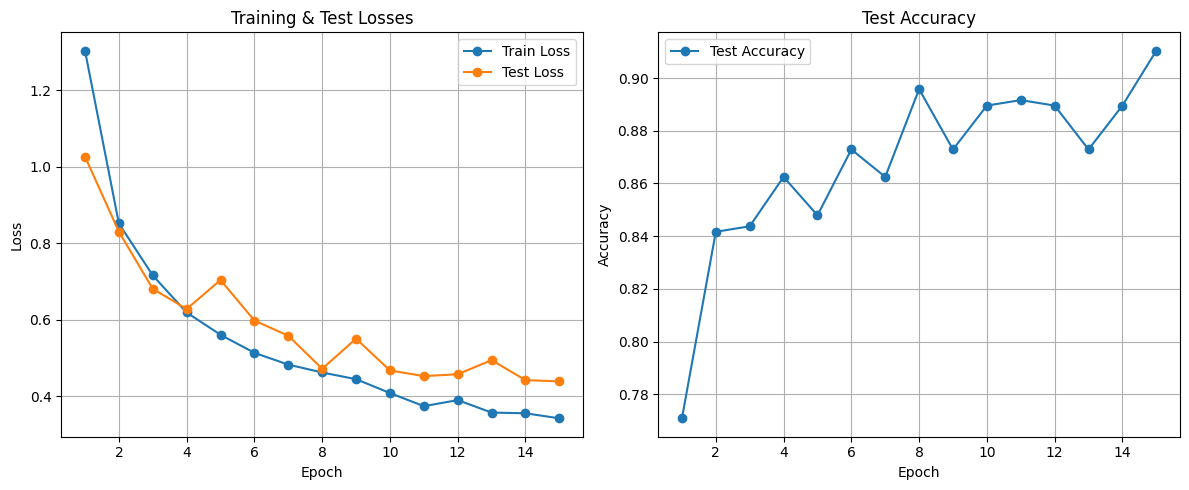

In [45]:
mnn.plot_losses_and_accuracy(figsize=(12,5))

In [ ]:
len(mnn.train_losses)

In [ ]:
len(mnn.train_loader), len(mnn.test_loader)